Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Load the Dual-Aware Training Data
# Make sure 'dual_mpc_ml_training_data.csv' is in the same folder as this notebook
df = pd.read_csv('dual_mpc_ml_training_data.csv')

# Drop any rows with NaN values to prevent math errors
df = df.dropna()

print(f"Dataset loaded successfully with {len(df)} samples.")
df.head()

Dataset loaded successfully with 2558 samples.


,time,ve,vf,vr,df,dr,d_safe_f,d_safe_r,delta_df,u_total,pwm
0,1.775668e+09,0.0,0.0000,0.0,0.2120,0.3046,0.25,0.25,-0.0380,0.0,0
1,1.775668e+09,0.0,0.0000,0.0,0.2120,0.3046,0.25,0.25,-0.0380,0.0,0
2,1.775668e+09,0.0,0.0014,0.0,0.2129,0.3053,0.25,0.25,-0.0371,0.0,0
3,1.775668e+09,0.0,0.0056,0.0,0.2159,0.3058,0.25,0.25,-0.0341,0.0,0
4,1.775668e+09,0.0,0.0113,0.0,0.2209,0.3063,0.25,0.25,-0.0291,0.0,0


Define Features and Scale the Data

In [ ]:
# 2. Define the exact 8 features the Dual-Aware system uses
features = [
    've',        # Ego velocity
    'vf',        # Front vehicle velocity
    'vr',        # Rear vehicle velocity
    'df',        # Distance to front vehicle
    'dr',        # Distance to rear vehicle
    'd_safe_f',  # Safe front distance threshold
    'd_safe_r',  # Safe rear distance threshold
    'delta_df'   # Error between actual and safe front distance
]

X = df[features]
y = df['e'] # Target is the smooth control effort (0.0 to 1.0)

# 3. Data Scaling (Crucial for Neural Networks to learn properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train/Test Split (80% for training, 20% for testing the accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data scaled and split into training and testing sets.")

Data scaled and split into training and testing sets.


Build and Train the Neural Network

In [ ]:
# 5. Build the Neural Network (8 Inputs -> 64 Hidden -> 32 Hidden -> 1 Output)
print("Training the Dual-Aware Neural Network. This might take a few seconds...")

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    learning_rate_init=0.001,
    random_state=42
)

# Train the model
mlp.fit(X_train, y_train)
print(f"Training complete! Iterations reached: {mlp.n_iter_}")
print("Training Complete!")

Training the Dual-Aware Neural Network. This might take a few seconds...
Training complete! Iterations reached: 106
Training Complete!


Evaluate and Visualize Accuracy

Mean Squared Error (MSE): 0.034567
Mean Absolute Error (MAE): 0.116538


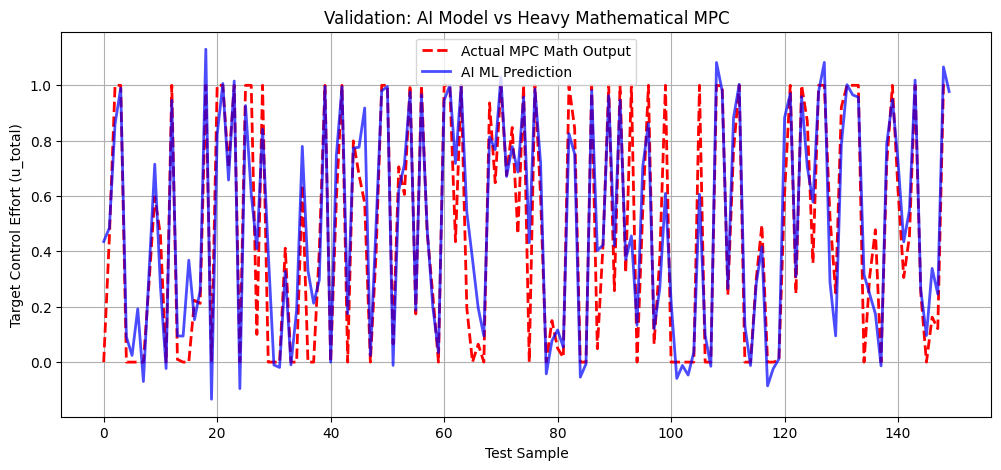

In [ ]:
# 6. Evaluate the Model's performance
predictions = mlp.predict(X_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")

# 7. Visualize the Accuracy (Predicted vs Actual Control Effort)
plt.figure(figsize=(12, 5))
# Plot just the first 150 samples so it's easy to read
samples_to_show = 150
plt.plot(y_test.values[:samples_to_show], label='Actual MPC Math Output', linestyle='dashed', color='red', linewidth=2)
plt.plot(predictions[:samples_to_show], label='AI ML Prediction', color='blue', alpha=0.7, linewidth=2)

plt.title('Validation: AI Model vs Heavy Mathematical MPC')
plt.xlabel('Test Sample')
plt.ylabel('Target Control Effort (u_total)')
plt.legend()
plt.grid(True)
plt.show()

Export to .npz for the Raspberry Pi

In [ ]:
# 8. Extract Raw Mathematical Weights and Scaler Parameters
# This bypasses the need for scikit-learn on the Raspberry Pi!

# Extract Scaler params
mean_vals = scaler.mean_
scale_vals = scaler.scale_

# Extract Neural Network params (Weights and Biases)
W1, W2, W3 = mlp.coefs_
b1, b2, b3 = mlp.intercepts_

# Save everything into a highly compressed NumPy archive
np.savez_compressed(
    'dual_aware_weights.npz',
    mean=mean_vals, scale=scale_vals,
    W1=W1, b1=b1,
    W2=W2, b2=b2,
    W3=W3, b3=b3
)

print("Model weights successfully extracted and saved to 'dual_aware_weights.npz'!")
print("Move this file to your Raspberry Pi.")

Model weights successfully extracted and saved to 'dual_aware_weights.npz'!
Move this file to your Raspberry Pi.
